In [ ]:
import os
from google.colab import drive
from pyspark.sql import SparkSession,Window
import pyspark.sql.functions as func


# Checking if the mounting point does exist or should we make a new mounting point

if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')

# we create a new spark session
spark=SparkSession.builder.getOrCreate()


In [ ]:
# reading the csv & make a pyspark dataframe

# check resource :
# https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.SparkSession.read.html (sparkSession.read => DataframeReader)
# https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrameReader.csv.html (DataframeReader.csv => Dataframe)
# https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.html#pyspark.sql.DataFrame

df_raw=spark.read.csv('/content/drive/MyDrive/Colab Notebooks/data/ensemble-de-donnees.csv',header=True,inferSchema=True)

In [ ]:
# performing a copy of the dataframe by select => returns a new dataframe
df_transformed=df_raw.selectExpr("*")

col_rename_mapping={
    'FTHG':'HomeTeamGoals',
    'FTAG':'AwayTeamGoals',
    'FTR':'FinalResult'
}

## rename columns
df_transformed=df_transformed.withColumnsRenamed(colsMap=col_rename_mapping)

# create new columns with dataframe expressions
df_transformed=df_transformed.withColumn('HomeTeamWin',func.when(df_transformed['FinalResult']=='H',1).otherwise(0))
df_transformed=df_transformed.withColumn('AwayTeamWin',func.when(df_transformed['FinalResult']=='A',1).otherwise(0))
df_transformed=df_transformed.withColumn('GameTie',func.when(df_transformed['FinalResult']=='D',1).otherwise(0))


df_transformed.show()

+--------+---+------+----------+------------------+--------------+-------------+-------------+-----------+-----------+-----------+-------+
|Match_ID|Div|Season|      Date|          HomeTeam|      AwayTeam|HomeTeamGoals|AwayTeamGoals|FinalResult|HomeTeamWin|AwayTeamWin|GameTie|
+--------+---+------+----------+------------------+--------------+-------------+-------------+-----------+-----------+-----------+-------+
|       1| D2|  2009|2010-04-04|        Oberhausen|Kaiserslautern|            2|            1|          H|          1|          0|      0|
|       2| D2|  2009|2009-11-01|       Munich 1860|Kaiserslautern|            0|            1|          A|          0|          1|      0|
|       3| D2|  2009|2009-10-04|     Frankfurt FSV|Kaiserslautern|            1|            1|          D|          0|          0|      1|
|       4| D2|  2009|2010-02-21|     Frankfurt FSV|     Karlsruhe|            2|            1|          H|          1|          0|      0|
|       5| D2|  2009|2009-1

In [ ]:
df_transformed=df_transformed.filter(df_transformed.Div=="D1").filter((2000<=df_transformed.Season) & (df_transformed.Season<=2015)).orderBy('Season',ascending=True)
df_transformed.show()

+--------+---+------+----------+--------------+--------------+-------------+-------------+-----------+-----------+-----------+-------+
|Match_ID|Div|Season|      Date|      HomeTeam|      AwayTeam|HomeTeamGoals|AwayTeamGoals|FinalResult|HomeTeamWin|AwayTeamWin|GameTie|
+--------+---+------+----------+--------------+--------------+-------------+-------------+-----------+-----------+-----------+-------+
|   34429| D1|  2000|2000-08-11|      Dortmund| Hansa Rostock|            1|            0|          H|          1|          0|      0|
|   34449| D1|  2000|2000-09-05|    Leverkusen|  Unterhaching|            1|            0|          H|          1|          0|      0|
|   34430| D1|  2000|2000-08-12| Bayern Munich|        Hertha|            4|            1|          H|          1|          0|      0|
|   34431| D1|  2000|2000-08-12|      Freiburg|     Stuttgart|            4|            0|          H|          1|          0|      0|
|   34432| D1|  2000|2000-08-12|       Hamburg|   Munic

In [ ]:
df_home_matches=df_transformed.groupBy(['HomeTeam','Season']).agg(
    func.sum('HomeTeamWin').alias('TotalHomeWin'),
    func.sum('AwayTeamWin').alias('TotalHomeLoss'),
    func.sum('GameTie').alias('TotalHomeTie'),
    func.sum('HomeTeamGoals').alias('HomeScoredGoals'),
    func.sum('AwayTeamGoals').alias('HomeAgainstGoals')
).orderBy('Season')
df_home_matches.show()

+--------------+------+------------+-------------+------------+---------------+----------------+
|      HomeTeam|Season|TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|
+--------------+------+------------+-------------+------------+---------------+----------------+
| Bayern Munich|  2000|          12|            4|           1|             37|              20|
|      Freiburg|  2000|           9|            3|           5|             36|              15|
|       Cottbus|  2000|          10|            6|           1|             27|              20|
|    Schalke 04|  2000|          12|            1|           4|             36|              13|
|     Wolfsburg|  2000|           8|            3|           6|             38|              18|
|        Hertha|  2000|          11|            4|           2|             38|              22|
|       FC Koln|  2000|           8|            4|           5|             33|              18|
|   Munich 1860|  2000|       

In [ ]:
df_away_matches=df_transformed.groupBy(['AwayTeam','Season']).agg(
    func.sum('AwayTeamWin').alias('TotalAwayWin'),
    func.sum('HomeTeamWin').alias('TotalAwayLoss'),
    func.sum('GameTie').alias('TotalAwayTie'),
    func.sum('HomeTeamGoals').alias('AwayAgainstGoals'),
    func.sum('AwayTeamGoals').alias('AwayScoredGoals')
).orderBy('Season')
df_away_matches.show()

+--------------+------+------------+-------------+------------+----------------+---------------+
|      AwayTeam|Season|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayAgainstGoals|AwayScoredGoals|
+--------------+------+------------+-------------+------------+----------------+---------------+
| Bayern Munich|  2000|           7|            5|           5|              17|             25|
|      Freiburg|  2000|           6|            6|           5|              22|             18|
|       Cottbus|  2000|           2|           13|           2|              32|             11|
|    Schalke 04|  2000|           6|            7|           4|              22|             29|
|     Wolfsburg|  2000|           4|            8|           5|              27|             22|
|        Hertha|  2000|           7|           10|           0|              30|             20|
|       FC Koln|  2000|           4|            8|           5|              34|             26|
|   Munich 1860|  2000|       

In [ ]:
df_home_matches = df_home_matches.withColumnRenamed("HomeTeam", "Team")
df_away_matches = df_away_matches.withColumnRenamed("AwayTeam", "Team")
df_merged=df_home_matches.join(df_away_matches,on=['Team','Season'])
df_merged.show(5)

+-------------+------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+----------------+---------------+
|         Team|Season|TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayAgainstGoals|AwayScoredGoals|
+-------------+------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+----------------+---------------+
|     Dortmund|  2013|          11|            4|           2|             41|              19|          11|            3|           3|              19|             39|
|Werder Bremen|  2010|           6|            5|           6|             26|              23|           4|            8|           5|              38|             21|
|      Hamburg|  2014|           6|            6|           5|             16|              18|           3|           11|           3|              32|   

In [ ]:
df_merged=df_merged.withColumns({
    "GoalsScored":func.col('HomeScoredGoals')+func.col('AwayScoredGoals'),
    "GoalsAgainst":func.col('HomeAgainstGoals')+func.col('AwayAgainstGoals'),
    "Win":func.col('TotalHomeWin')+func.col('TotalAwayWin'),
    "Loss":func.col('TotalHomeLoss')+func.col('TotalAwayLoss'),
    "Tie":func.col('TotalHomeTie')+func.col('TotalAwayTie')
})
df_merged.show()

+--------------+------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+----------------+---------------+-----------+------------+---+----+---+
|          Team|Season|TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayAgainstGoals|AwayScoredGoals|GoalsScored|GoalsAgainst|Win|Loss|Tie|
+--------------+------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+----------------+---------------+-----------+------------+---+----+---+
|      Dortmund|  2013|          11|            4|           2|             41|              19|          11|            3|           3|              19|             39|         80|          38| 22|   7|  5|
| Werder Bremen|  2010|           6|            5|           6|             26|              23|           4|            8|           5|              38|             21

In [ ]:
df_processed = df_merged.withColumn("TotalGames", func.col("Win") + func.col("Loss") + func.col("Tie")) \
    .withColumn("GoalDifferentials", func.col("GoalsScored") - func.col("GoalsAgainst")) \
    .withColumn("WinPercentage", func.round(func.col("Win") / func.col("TotalGames"),3)) \
    .withColumn("GoalsPerGame", func.round(func.col("GoalsScored") / func.col("TotalGames"),3)) \
    .withColumn("GoalsAgainstPerGame", func.round(func.col("GoalsAgainst") / func.col("TotalGames"),3))

df_processed.show()

+--------------+------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+----------------+---------------+-----------+------------+---+----+---+----------+-----------------+-------------+------------+-------------------+
|          Team|Season|TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayAgainstGoals|AwayScoredGoals|GoalsScored|GoalsAgainst|Win|Loss|Tie|TotalGames|GoalDifferentials|WinPercentage|GoalsPerGame|GoalsAgainstPerGame|
+--------------+------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+----------------+---------------+-----------+------------+---+----+---+----------+-----------------+-------------+------------+-------------------+
|      Dortmund|  2013|          11|            4|           2|             41|              19|          11|            3|           3|            

In [ ]:
# Winodw functions

season_window=Window.partitionBy('Season').orderBy(
    func.col('GoalDifferentials').desc(),
    func.col('WinPercentage').desc()
)
df_processed=df_processed.withColumn('TeamPosition',func.row_number().over(season_window))

In [42]:
df_champions = df_processed.filter(func.col("TeamPosition") == 1)

df_processed.write.partitionBy("Season").mode("overwrite").parquet("/content/drive/MyDrive/Colab Notebooks/data/football_stats_partitioned")

df_champions.write.mode("overwrite").parquet("/content/drive/MyDrive/Colab Notebooks/data/football_top_teams")

In [43]:
import pandas as pd
df_parque_stats=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/data/football_stats_partitioned')
df_parque_top=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/data/football_top_teams')
display(df_parque_stats)
display(df_parque_top)


,Team,TotalHomeWin,TotalHomeLoss,TotalHomeTie,HomeScoredGoals,HomeAgainstGoals,TotalAwayWin,TotalAwayLoss,TotalAwayTie,AwayAgainstGoals,...,Win,Loss,Tie,TotalGames,GoalDifferentials,WinPercentage,GoalsPerGame,GoalsAgainstPerGame,TeamPosition,Season
0,Schalke 04,12,1,4,36,13,6,7,4,22,...,18,8,8,34,30,0.529,1.912,1.029,1,2000
1,Bayern Munich,12,4,1,37,20,7,5,5,17,...,19,9,6,34,25,0.559,1.824,1.088,2,2000
2,Dortmund,9,4,4,34,20,7,4,6,22,...,16,8,10,34,20,0.471,1.824,1.235,3,2000
3,Freiburg,9,3,5,36,15,6,6,5,22,...,15,9,10,34,17,0.441,1.588,1.088,4,2000
4,Wolfsburg,8,3,6,38,18,4,8,5,27,...,12,11,11,34,15,0.353,1.765,1.324,5,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Darmstadt,2,9,6,15,29,7,5,5,24,...,9,14,11,34,-15,0.265,1.118,1.559,14,2015
284,Hoffenheim,6,5,6,22,25,3,10,4,29,...,9,15,10,34,-15,0.265,1.147,1.588,15,2015
285,Ein Frankfurt,6,5,6,22,24,3,11,3,28,...,9,16,9,34,-18,0.265,1.000,1.529,16,2015
286,Stuttgart,6,10,1,22,32,3,9,5,43,...,9,19,6,34,-25,0.265,1.471,2.206,17,2015


,Team,Season,TotalHomeWin,TotalHomeLoss,TotalHomeTie,HomeScoredGoals,HomeAgainstGoals,TotalAwayWin,TotalAwayLoss,TotalAwayTie,...,GoalsAgainst,Win,Loss,Tie,TotalGames,GoalDifferentials,WinPercentage,GoalsPerGame,GoalsAgainstPerGame,TeamPosition
0,Schalke 04,2000,12,1,4,36,13,6,7,4,...,35,18,8,8,34,30,0.529,1.912,1.029,1
1,Bayern Munich,2001,12,0,5,42,10,8,6,3,...,25,20,6,8,34,40,0.588,1.912,0.735,1
2,Bayern Munich,2002,13,1,3,37,12,10,4,3,...,25,23,5,6,34,45,0.676,2.059,0.735,1
3,Werder Bremen,2003,11,2,4,42,21,11,2,4,...,38,22,4,8,34,41,0.647,2.324,1.118,1
4,Bayern Munich,2004,14,1,2,44,14,10,4,3,...,33,24,5,5,34,42,0.706,2.206,0.971,1
5,Werder Bremen,2005,12,2,3,50,18,9,4,4,...,37,21,6,7,34,42,0.618,2.324,1.088,1
6,Werder Bremen,2006,11,5,1,33,18,9,3,5,...,40,20,8,6,34,36,0.588,2.235,1.176,1
7,Bayern Munich,2007,12,0,5,41,8,10,2,5,...,21,22,2,10,34,47,0.647,2.000,0.618,1
8,Wolfsburg,2008,16,0,1,51,13,5,7,5,...,41,21,7,6,34,39,0.618,2.353,1.206,1
9,Bayern Munich,2009,12,1,4,39,13,8,3,6,...,31,20,4,10,34,41,0.588,2.118,0.912,1


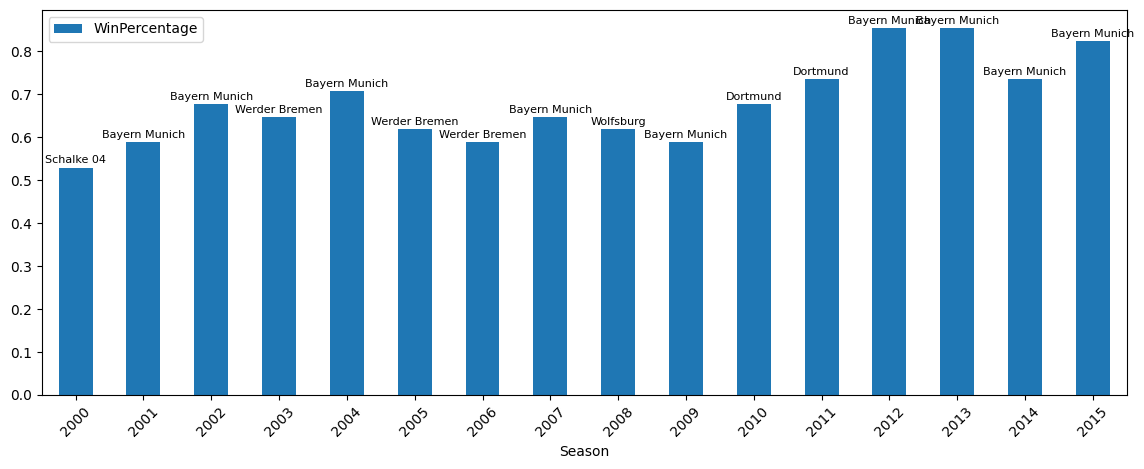

In [46]:
ax_1 = df_parque_top.plot.bar(x='Season', y='WinPercentage', figsize=(14, 5), rot=45)

for i, (val, team) in enumerate(zip(df_parque_top['WinPercentage'], df_parque_top['Team'])):
    ax_1.text(i, val + 0.01, team, ha='center', fontsize=8)

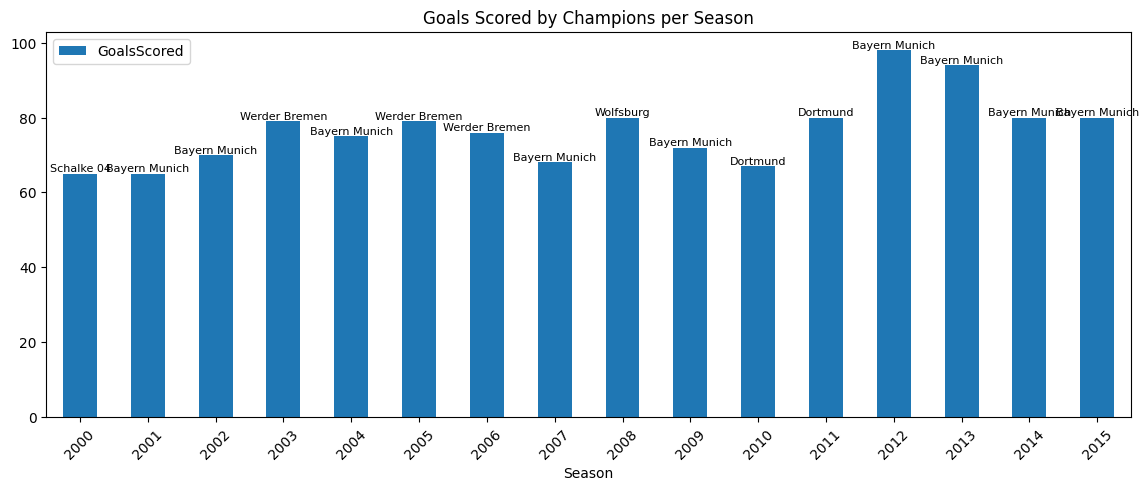

In [47]:
ax_2 = df_parque_top.plot.bar(x='Season', y='GoalsScored', figsize=(14, 5), rot=45, title='Goals Scored by Champions per Season')
for i, (val, team) in enumerate(zip(df_parque_top['GoalsScored'], df_parque_top['Team'])):
    ax_2.text(i, val + 0.5, team, ha='center', fontsize=8)

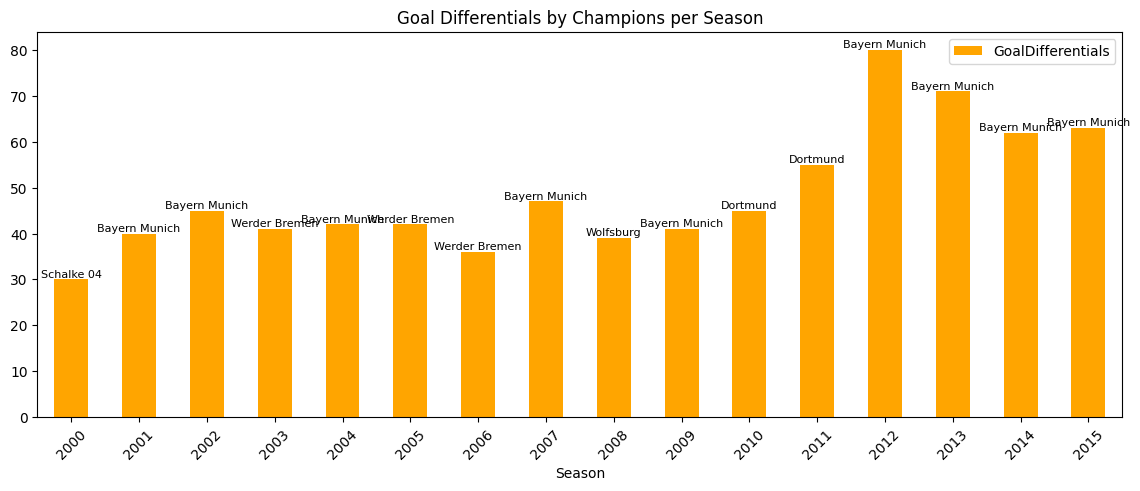

In [48]:
ax_3 = df_parque_top.plot.bar(x='Season', y='GoalDifferentials', figsize=(14, 5), rot=45, title='Goal Differentials by Champions per Season', color='orange')
for i, (val, team) in enumerate(zip(df_parque_top['GoalDifferentials'], df_parque_top['Team'])):
    ax_3.text(i, val + 0.5, team, ha='center', fontsize=8)